# 02 · Semi-supervised learning: 50 labels instead of 1,347

**Scenario.** We have plenty of unlabelled images and can afford to label only 50.  
**Method** (Géron, Ch. 9, pp. 254-256): cluster the training set into 50 groups, label only the image closest to each centroid (the *representative* images), then propagate those labels to similar images.

In production the "human" is either the ground truth acting as an oracle (reproducible runs) or a real person using the **Label** page of the web UI (`LABEL_SOURCE=human`).

In [1]:
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore", category=FutureWarning)
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from unsupervised_mlops import plots  # shared plot style
from unsupervised_mlops.data import load_digits_split
pd.set_option("display.precision", 4)
split = load_digits_split(random_state=42)
split.sizes

{'n_train': 1347, 'n_test': 450}

In [2]:
from unsupervised_mlops.clustering_features import make_logreg
from unsupervised_mlops.semi_supervised import (find_representatives, propagate_labels,
                                                partial_propagation_mask, active_learning, random_label_curve)
k = 50
Xtr, ytr, Xte, yte = split.X_train, split.y_train, split.X_test, split.y_test
random50 = make_logreg(42).fit(Xtr[:k], ytr[:k]).score(Xte, yte)
print(f"50 random labels -> test accuracy {random50:.4f}")

50 random labels -> test accuracy 0.8267


## Label the 50 representative images instead

In [3]:
kmeans, dist, rep_idx = find_representatives(Xtr, k, random_state=42)
y_rep = ytr[rep_idx]                      # the oracle plays the human labeller
rep_acc = make_logreg(42).fit(Xtr[rep_idx], y_rep).score(Xte, yte)
print(f"50 representative labels -> test accuracy {rep_acc:.4f}")
fig, axes = plt.subplots(5, 10, figsize=(9, 5))
for ax, i, lab in zip(axes.ravel(), rep_idx, y_rep):
    plots._digit(ax, Xtr[i], str(lab))
fig.suptitle("The 50 representative images (one per cluster)", x=0.01, ha="left", fontsize=10, fontweight="bold")
plt.tight_layout()

50 representative labels -> test accuracy 0.8956


## Propagate the labels: to the whole cluster, or only to the closest 20 %

In [4]:
y_prop = propagate_labels(kmeans.labels_, y_rep)
full = make_logreg(42).fit(Xtr, y_prop).score(Xte, yte)
mask = partial_propagation_mask(dist, kmeans.labels_, 20); mask[rep_idx] = True
partial = make_logreg(42).fit(Xtr[mask], y_prop[mask]).score(Xte, yte)
pd.DataFrame({
    "training set": ["50 random", "50 representatives", "full propagation", "partial propagation (20%)", "all true labels"],
    "n images": [50, 50, len(Xtr), int(mask.sum()), len(Xtr)],
    "label accuracy": [1.0, 1.0, np.mean(y_prop == ytr), np.mean(y_prop[mask] == ytr[mask]), 1.0],
    "test accuracy": [random50, rep_acc, full, partial, make_logreg(42).fit(Xtr, ytr).score(Xte, yte)],
}).round(4)

,training set,n images,label accuracy,test accuracy
0,50 random,50,1.0000,0.8267
1,50 representatives,50,1.0000,0.8956
2,full propagation,1347,0.9354,0.9089
3,partial propagation (20%),288,0.9826,0.9244
4,all true labels,1347,1.0000,0.9733


Propagating to *every* image in a cluster also copies the label to boundary images, which are often a different digit (label accuracy 93.5%). Keeping only the 20% closest to each centroid trades coverage for label quality (about 98% correct), and the model improves.

## The coverage / quality trade-off

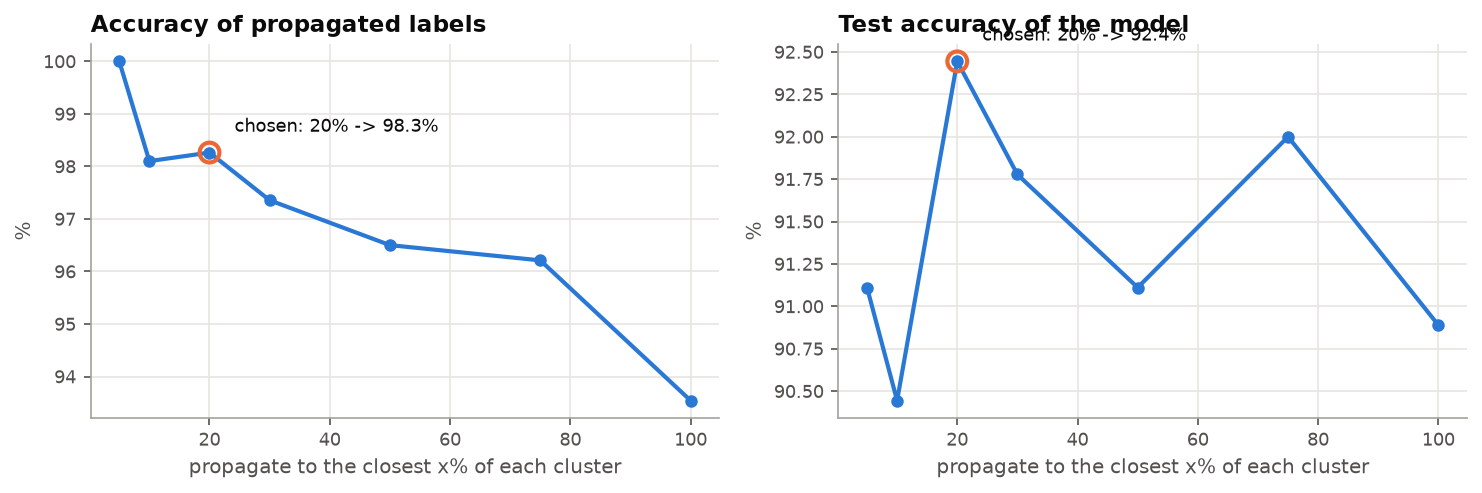

In [5]:
rows = []
for p in [5, 10, 20, 30, 50, 75, 100]:
    m = partial_propagation_mask(dist, kmeans.labels_, p); m[rep_idx] = True
    rows.append({"percentile": p, "n_train": int(m.sum()), "label_accuracy": np.mean(y_prop[m] == ytr[m]),
                 "test_accuracy": make_logreg(42).fit(Xtr[m], y_prop[m]).score(Xte, yte)})
sweep = pd.DataFrame(rows)
plots.plot_percentile_sweep(sweep, 20, "/tmp/sweep.png")
from IPython.display import Image
Image("/tmp/sweep.png")

## How sensitive is this to labelling mistakes?

Every representative label is copied to dozens of images, so **one wrong label hurts much more than in ordinary supervised learning**. Here we flip *m* of the 50 representative labels at random (10 repetitions each).

In [6]:
rng = np.random.default_rng(0)
rows = []
for m_wrong in [0, 1, 2, 3, 5]:
    accs = []
    for rep in range(10):
        y_noisy = y_rep.copy()
        flip = rng.choice(k, size=m_wrong, replace=False)
        y_noisy[flip] = (y_noisy[flip] + rng.integers(1, 10, size=m_wrong)) % 10
        yp = propagate_labels(kmeans.labels_, y_noisy)
        accs.append(make_logreg(42).fit(Xtr[mask], yp[mask]).score(Xte, yte))
    rows.append({"wrong representative labels": m_wrong, "mean test accuracy": np.mean(accs), "worst": np.min(accs)})
pd.DataFrame(rows).round(4)

,wrong representative labels,mean test accuracy,worst
0,0,0.9244,0.9244
1,1,0.9007,0.8844
2,2,0.8718,0.8533
3,3,0.8540,0.8244
4,5,0.7996,0.7689


Each wrong representative label costs about 2.4 percentage points on average, and up to 4 in the worst case. That is why the pipeline has a **champion-vs-challenger gate**.

### Reproducing the labelling incident from the live system
In the end-to-end test, a person typed all 50 labels in the web UI and got the first one wrong (label + 1). Here is the same mistake, and what the deployment gate does with it.

In [7]:
from unsupervised_mlops.gates import evaluate_gates
y_typo = y_rep.copy(); y_typo[0] = (y_typo[0] + 1) % 10
yp = propagate_labels(kmeans.labels_, y_typo)
acc_typo = make_logreg(42).fit(Xtr[mask], yp[mask]).score(Xte, yte)
print(f"one wrong label: semi-supervised accuracy {partial:.4f} -> {acc_typo:.4f}")
gates = {"supervised_min_accuracy": 0.95, "semi_supervised_min_accuracy": 0.85,
         "anomaly_max_clean_false_positive_pct": 8.0, "anomaly_min_detection_pct": {}}
base = {"supervised_accuracy": 0.976, "anomaly_clean_false_positive_pct": 2.9}
checks = evaluate_gates({**base, "semi_supervised_accuracy": acc_typo}, {**base, "semi_supervised_accuracy": partial}, gates)
pd.DataFrame(checks)

one wrong label: semi-supervised accuracy 0.9244 -> 0.8889


,check,value,limit,passed
0,supervised accuracy,0.9760,0.9500,True
1,semi-supervised accuracy,0.8889,0.8500,True
2,anomaly false positives on clean digits (%),2.9000,8.0000,True
3,supervised_accuracy vs champion,0.9760,0.9710,True
4,semi_supervised_accuracy vs champion,0.8889,0.9194,False


The challenger is still above the absolute 85% floor, but it is more than 0.5 pp worse than the champion, so it is **not deployed**.

## Active learning: where should the next labels go?

The book's "Active Learning" box suggests *uncertainty sampling*: ask the human about the images the model is least sure of. We start from the partially propagated set and query 10 more labels per round.

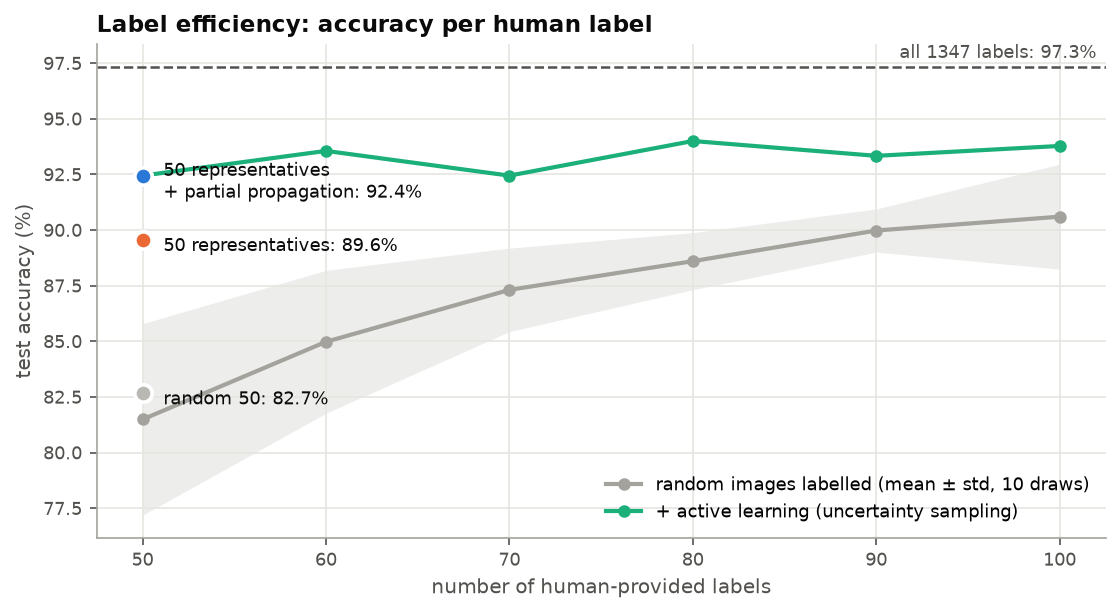

In [8]:
al = active_learning(Xtr, ytr, mask, y_prop.copy(), Xte, yte, n_human_start=k, rounds=5, queries_per_round=10)
rc = random_label_curve(Xtr, ytr, Xte, yte, sorted(al.human_labels), list(range(10)))
metrics = {"n_human_labels": k, "random50_accuracy": random50, "representative50_accuracy": rep_acc,
           "partial_propagation_accuracy": partial,
           "fully_supervised_accuracy": make_logreg(42).fit(Xtr, ytr).score(Xte, yte)}
plots.plot_label_efficiency(metrics, rc, al, len(Xtr), "/tmp/label_eff.png")
Image("/tmp/label_eff.png")

## Takeaways

* Choosing *which* 50 images to label matters as much as how many: representatives plus partial propagation reach about 92% accuracy, against about 83% for 50 random labels, using 3.7% of the labels.
* The 20% propagation percentile is the book's choice. The sweep above is not monotone, so on this data 20% is a sensible setting rather than a proven optimum.
* Propagated labels are only as good as the representatives, so label quality has to be checked (agreement checks in the UI, quality gates in the pipeline).
* Uncertainty sampling makes further labels count more than random ones. This is a single run (+1.4 pp for 50 more labels, i.e. about 6 test images), so treat it as indicative.